# PIIT Assign1 - Muhammad Rasul

## Assignment Details 
- Create notebook that uses the airquality dataset from pydataset and walks students through core pandas skills: structure, head/tail, selects, filters, missing values, duplicates, sorting, and simple aggregations.

## 
Practice Exercises
    - Inspecting structure: shape, dtypes, info, head, tail
    - Summary stats: describe, nunique
    - Missing values: isna, fillna (median/mean imputation)
    - Selecting columns/rows: lists, iloc, boolean masks, isin
    - Filtering with conditions and ranges 
    - Sorting by multiple columns
    - Duplicates: duplicated, drop_duplicates
    - Derived columns & categorization: arithmetic, pd.cut
    - Groupby & aggregation: agg, boolean-to-int counting
    - (Optional) quick sanity plots

In [1]:
## Few Initial Commands to help you load the data

In [2]:
#!pip install pydataset

In [3]:
# Install libraries in not available
import pandas as pd
import numpy as np
from pydataset import data

In [4]:
# Option A: Load directly from pydataset
df = data('airquality')

In [5]:
df.shape

(153, 6)

In [6]:
df.head(2)

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2


## Tasks

## T1. Inspect the structure
- Show the shape (rows, columns)
- List column names and dtypes
- Display the first 5 and last 5 rows

> **Hints:** `df.shape`, `df.dtypes`, `df.columns`, `df.head()`, `df.tail()`, `df.info()`

In [7]:
# ==============================================================================
#  STRUCTURAL INSPECTION & INITIAL AUDIT
# ==============================================================================

# 1. Structural dimensions (Shape)
rows, cols = df.shape
print("--- DATASET MATRIX DIMENSIONS ---")
print(f"Total Observations (Rows): {rows}")
print(f"Total Attributes (Columns): {cols}")
print("-" * 40)

# 2. Extract column metadata (Names and Data Types)
print("\n--- ATTRIBUTE DATA TYPES & SCHEMA ---")
print(df.dtypes)
print("-" * 40)

# 3. View boundaries (First 5 and Last 5 rows)
print("\n--- FIRST 5 OBSERVATIONS ---")
print(df.head(5))

print("\n--- LAST 5 OBSERVATIONS ---")
print(df.tail(5))
print("-" * 40)

# 4. Thoroughness Check: Summary Info & Missing Value Counts
print("\n--- DATA ARCHITECTURE SUMMARY & NULL AUDIT ---")
print(df.info())
print("\nMissing Values per Column:")
print(df.isnull().sum())


--- DATASET MATRIX DIMENSIONS ---
Total Observations (Rows): 153
Total Attributes (Columns): 6
----------------------------------------

--- ATTRIBUTE DATA TYPES & SCHEMA ---
Ozone      float64
Solar.R    float64
Wind       float64
Temp         int64
Month        int64
Day          int64
dtype: object
----------------------------------------

--- FIRST 5 OBSERVATIONS ---
   Ozone  Solar.R  Wind  Temp  Month  Day
1   41.0    190.0   7.4    67      5    1
2   36.0    118.0   8.0    72      5    2
3   12.0    149.0  12.6    74      5    3
4   18.0    313.0  11.5    62      5    4
5    NaN      NaN  14.3    56      5    5

--- LAST 5 OBSERVATIONS ---
     Ozone  Solar.R  Wind  Temp  Month  Day
149   30.0    193.0   6.9    70      9   26
150    NaN    145.0  13.2    77      9   27
151   14.0    191.0  14.3    75      9   28
152   18.0    131.0   8.0    76      9   29
153   20.0    223.0  11.5    68      9   30
----------------------------------------

--- DATA ARCHITECTURE SUMMARY & NULL AU

## T2. Basic summary stats
- Produce descriptive statistics for numeric columns.
- For each column, show number of unique values.

> **Hints:** `df.describe()`, `df.nunique()`

In [8]:
# code for T2
# ==============================================================================
# DESCRIPTIVE STATISTICS & CARDINALITY AUDIT
# ==============================================================================
# Descriptive statistics for numeric columns
print("--- DESCRIPTIVE STATISTICS ---")
summary_stats = df.describe()
print(summary_stats)
print("-" * 50)

#Cardinality: Number of unique values per column
print("\n--- UNIQUE VALUE COUNTS (CARDINALITY) ---")
unique_counts = df.nunique()
print(unique_counts)
print("-" * 50)

--- DESCRIPTIVE STATISTICS ---
            Ozone     Solar.R        Wind        Temp       Month         Day
count  116.000000  146.000000  153.000000  153.000000  153.000000  153.000000
mean    42.129310  185.931507    9.957516   77.882353    6.993464   15.803922
std     32.987885   90.058422    3.523001    9.465270    1.416522    8.864520
min      1.000000    7.000000    1.700000   56.000000    5.000000    1.000000
25%     18.000000  115.750000    7.400000   72.000000    6.000000    8.000000
50%     31.500000  205.000000    9.700000   79.000000    7.000000   16.000000
75%     63.250000  258.750000   11.500000   85.000000    8.000000   23.000000
max    168.000000  334.000000   20.700000   97.000000    9.000000   31.000000
--------------------------------------------------

--- UNIQUE VALUE COUNTS (CARDINALITY) ---
Ozone       67
Solar.R    117
Wind        31
Temp        40
Month        5
Day         31
dtype: int64
--------------------------------------------------


## T3. Missing values
- Count missing values per column.
- Create a copy `df_mv` where you impute:
  - `Ozone`: fill with the column median (numeric)
  - `Solar.R`: fill with the column mean (numeric)
- Briefly comment: why might median be preferred over mean in some cases? (Add a markdown cell.)

> **Hints:** `df.isna().sum()`, `df.copy()`, `fillna()`

In [9]:
# code for T3
# ==============================================================================
# MISSING VALUE AUDIT & ROBUST IMPUTATION
# ==============================================================================

# Profile missing data volume before making adjustments
print("--- INITIAL MISSING VALUE COUNT ---")
null_counts = df.isna().sum()
print(null_counts)
print("-" * 50)

# 2. Instantiate a safe deep copy for clean statistical handling
df_mv = df.copy()

# 3. Calculate target summary parameters from the baseline distribution
ozone_median = df_mv["Ozone"].median()
solar_mean = df_mv["Solar.R"].mean()

# 4. Impute missing entries directly using specialized column parameters
df_mv["Ozone"] = df_mv["Ozone"].fillna(ozone_median)
df_mv["Solar.R"] = df_mv["Solar.R"].fillna(solar_mean)

# 5. Thoroughness Verification: Ensure all null indicators are successfully purged
print("\n--- POST-IMPUTATION VALIDATION CHECK ---")
print(df_mv.isna().sum())
print("-" * 50)



--- INITIAL MISSING VALUE COUNT ---
Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64
--------------------------------------------------

--- POST-IMPUTATION VALIDATION CHECK ---
Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64
--------------------------------------------------


#### Why Median is Preferred Over Mean

The **median** is preferred over the mean primarily because it is **robust to outliers and skewed data**. While extreme values heavily distort the mean, they do not impact the median.

#### 1. Resistance to Outliers
The mean adds all values together, meaning exceptionally high or low numbers pull the average away from the true center. The median simply picks the middle value, ignoring how extreme the ends are.

* **Example:** Consider five individual salaries: \$40k, \$45k, \$50k, \$55k, and \$1M.
  * **Mean:** \$238,000 *(Misleadingly high; nobody earns anywhere near this).*
  * **Median:** \$50,000 *(Accurately represents the typical person in the group).*

#### 2. Handling Highly Skewed Distributions
When data is asymmetrical, the mean gets pulled toward the long tail of the distribution. 

* **Real-world data:** Real estate values, household wealth, and city populations are almost always heavily right-skewed. 
* **Standard practice:** This is why economic reports always reference **Median Household Income** or **Median Home Price** rather than the average (mean).

#### 3. Dealing with Open-Ended Data
Surveys often use open-ended top categories (e.g., an age question with options ending in "65+"). 

* **The Problem:** You cannot calculate a precise mean for "65+" because the exact numbers are unknown.
* **The Fix:** You **can** easily find the median as long as the middle data point falls into a defined numeric bracket.

#### 4. Robust Imputation in Data Science
When cleaning missing data (like filling gaps in air quality columns):

* Filling missing gaps with the mean introduces bias if the column has extreme spikes (e.g., a single day with a massive pollution spike).
* Imputing with the median ensures your substituted values align with a highly typical day of data.


## T4. Selecting columns & rows
- Select the columns: `Ozone`, `Solar.R`, `Temp` into a new DataFrame `df_sel`.
- Select the first **10 rows** of `df_sel`.
- Select rows where `Month` is **May (5)** or **June (6)** only.

> **Hints:** Column lists, `iloc`, boolean masks, `isin`

In [10]:
# code for T4
# ==============================================================================
# SUBSET SELECTION: COLUMNS, POSITION, AND LOGICAL CONDITIONING
# ==============================================================================

# Feature Selection: Extract explicit columns into df_sel
df_sel = df[["Ozone", "Solar.R", "Temp", "Month"]].copy() 
# Note: 'Month' is kept here to fulfill the third structural filter rule safely

# Positional Slicing: Isolate the first 10 rows using index-based locations
print("--- FIRST 10 ROWS OF SELECTED COLUMNS ---")
df_first_10 = df_sel.iloc[0:10]
print(df_first_10[["Ozone", "Solar.R", "Temp"]])
print("-" * 50)

# Categorical Filtering: Extract records belonging only to May (5) or June (6)
# Utilizing the clean vector-optimized .isin() method to handle multiple conditions
print("\n--- FILTERED BOUNDARIES (MAY & JUNE DATA ONLY) ---")
df_may_june = df_sel[df_sel["Month"].isin([5, 6])]
print(df_may_june.head())

# Formally finalize df_sel structure by removing Month to strictly match target prompt columns
df_sel = df_sel[["Ozone", "Solar.R", "Temp"]]
print(f"\nFinal df_sel structural footprint shape: {df_sel.shape}")

--- FIRST 10 ROWS OF SELECTED COLUMNS ---
    Ozone  Solar.R  Temp
1    41.0    190.0    67
2    36.0    118.0    72
3    12.0    149.0    74
4    18.0    313.0    62
5     NaN      NaN    56
6    28.0      NaN    66
7    23.0    299.0    65
8    19.0     99.0    59
9     8.0     19.0    61
10    NaN    194.0    69
--------------------------------------------------

--- FILTERED BOUNDARIES (MAY & JUNE DATA ONLY) ---
   Ozone  Solar.R  Temp  Month
1   41.0    190.0    67      5
2   36.0    118.0    72      5
3   12.0    149.0    74      5
4   18.0    313.0    62      5
5    NaN      NaN    56      5

Final df_sel structural footprint shape: (153, 3)


## T5. Filtering & conditions
- Filter rows where `Ozone` > 100 **and** `Temp` >= 85.
- Filter rows where `Solar.R` is missing.
- Filter rows for **July (7)** with `Ozone` between **50 and 100** (inclusive).

> **Hints:** Combined boolean conditions with `&`, `|`, parentheses; `between()`

In [11]:
# code for T5
# ==============================================================================
# COMPLEX BOOLEAN FILTERING & CONDITIONAL EXPRESSIONS
# ==============================================================================

# Intersection Filter: Ozone > 100 AND Temp >= 85
# Rule: Use bitwise & and wrap each conditional sub-clause in strict parentheses
print("--- EXTRA HIGH-POLLUTION & HOT DAYS (OZONE > 100 & TEMP >= 85) ---")
df_extreme_weather = df[(df["Ozone"] > 100) & (df["Temp"] >= 85)]
print(df_extreme_weather)
print(f"Total Matches: {len(df_extreme_weather)} days.")
print("-" * 65)

# Null Value Isolation: Rows where Solar.R data collection failed
print("\n--- DAYS MISSING SOLAR RADIATION DATA ---")
df_missing_solar = df[df["Solar.R"].isnull()]
print(df_missing_solar)
print(f"Total Missing Records: {len(df_missing_solar)} days.")
print("-" * 65)

# Double-Bounded Subset: July days with Ozone between 50 and 100 inclusive
# Optimization: Utilizing the vectorized .between() method for accurate inclusive edge bounds
print("\n--- MODERATE-TO-HIGH OZONE DAYS IN JULY (50 <= OZONE <= 100) ---")
df_july_moderate = df[(df["Month"] == 7) & (df["Ozone"].between(50, 100))]
print(df_july_moderate)
print(f"Total Matches: {len(df_july_moderate)} days.")
print("-" * 65)


--- EXTRA HIGH-POLLUTION & HOT DAYS (OZONE > 100 & TEMP >= 85) ---
     Ozone  Solar.R  Wind  Temp  Month  Day
86   108.0    223.0   8.0    85      7   25
99   122.0    255.0   4.0    89      8    7
101  110.0    207.0   8.0    90      8    9
121  118.0    225.0   2.3    94      8   29
Total Matches: 4 days.
-----------------------------------------------------------------

--- DAYS MISSING SOLAR RADIATION DATA ---
    Ozone  Solar.R  Wind  Temp  Month  Day
5     NaN      NaN  14.3    56      5    5
6    28.0      NaN  14.9    66      5    6
11    7.0      NaN   6.9    74      5   11
27    NaN      NaN   8.0    57      5   27
96   78.0      NaN   6.9    86      8    4
97   35.0      NaN   7.4    85      8    5
98   66.0      NaN   4.6    87      8    6
Total Missing Records: 7 days.
-----------------------------------------------------------------

--- MODERATE-TO-HIGH OZONE DAYS IN JULY (50 <= OZONE <= 100) ---
    Ozone  Solar.R  Wind  Temp  Month  Day
66   64.0    175.0   4.6    83 

## T6. Sorting
- Sort the dataset by `Ozone` **descending** and `Temp` **ascending** (multi-column sort).
- Sort the dataset by `Month` then `Day` to get chronological order.

> **Hints:** `sort_values(by=[...], ascending=[...])`

In [12]:
# code for T6
# ==============================================================================
# DATASET RE-ORDERING & MULTI-COLUMN SORTING HIERARCHIES
# ==============================================================================

# Multi-Column Mixed Direction Sort: Ozone Descending, Temp Ascending
# Rationale: Sorts peak pollution first. If Ozone levels match, cooler days appear first.
print("--- SISTER METRIC SORT (OZONE DESCENDING, TEMP ASCENDING) ---")
df_pollution_sort = df.sort_values(by=["Ozone", "Temp"], ascending=[False, True])
print(df_pollution_sort.head(10))
print("-" * 75)

# Chronological Calendar Sort: Month Ascending, Day Ascending
# Rationale: Standardizes row matrices back to a sequential calendar timeline.
print("\n--- RE-ESTABLISHED CHRONOLOGICAL CALENDAR MATRIX ---")
df_chronological = df.sort_values(by=["Month", "Day"], ascending=[True, True])
print(df_chronological.head(10))
print("-" * 75)


--- SISTER METRIC SORT (OZONE DESCENDING, TEMP ASCENDING) ---
     Ozone  Solar.R  Wind  Temp  Month  Day
117  168.0    238.0   3.4    81      8   25
62   135.0    269.0   4.1    84      7    1
99   122.0    255.0   4.0    89      8    7
121  118.0    225.0   2.3    94      8   29
30   115.0    223.0   5.7    79      5   30
101  110.0    207.0   8.0    90      8    9
86   108.0    223.0   8.0    85      7   25
69    97.0    267.0   6.3    92      7    8
70    97.0    272.0   5.7    92      7    9
124   96.0    167.0   6.9    91      9    1
---------------------------------------------------------------------------

--- RE-ESTABLISHED CHRONOLOGICAL CALENDAR MATRIX ---
    Ozone  Solar.R  Wind  Temp  Month  Day
1    41.0    190.0   7.4    67      5    1
2    36.0    118.0   8.0    72      5    2
3    12.0    149.0  12.6    74      5    3
4    18.0    313.0  11.5    62      5    4
5     NaN      NaN  14.3    56      5    5
6    28.0      NaN  14.9    66      5    6
7    23.0    299.0   8.

## T7 Duplicates
- Check if there are any fully duplicated rows.
- Intentionally create a few duplicate rows (e.g., duplicate first 3 rows) into `df_dup`.
- Remove duplicates and report how many were removed.

> **Hints:** `df.duplicated()`, `pd.concat([...])`, `drop_duplicates()`

In [13]:
# code for T7
# ==============================================================================
# DUPLICATION AUDITING, ARTIFICIAL INJECTION, AND DEDUPLICATION REPORTING
# ==============================================================================

# 1. Baseline Audit: Check for existing full-row duplication
print("--- BASELINE DUPLICATION MATRIX CHECK ---")
any_initial_dups = df.duplicated().any()
total_initial_dups = df.duplicated().sum()
print(f"Are there any initial duplicate rows? {any_initial_dups}")
print(f"Total baseline duplicate row count: {total_initial_dups}")
print("-" * 65)

# 2. Injection: Intentionally slice the first 3 rows and append them to create df_dup
df_first_three = df.iloc[0:3]
df_dup = pd.concat([df, df_first_three], ignore_index=True)

print("\n--- POST-INJECTION RECORD AUDIT ---")
print(f"Original row count: {len(df)}")
print(f"Row count after duplicate injection: {len(df_dup)}")
print(f"Validated duplicate count in df_dup: {df_dup.duplicated().sum()}")
print("-" * 65)

# 3. Purge and Report: Deduplicate the DataFrame and measure the structural delta
pre_clean_count = len(df_dup)
df_cleaned = df_dup.drop_duplicates(keep="first")
post_clean_count = len(df_cleaned)
rows_purged = pre_clean_count - post_clean_count

print("\n--- PROGRAMMATIC CLEANUP REPORT ---")
print(f"Rows Ingested for Cleanup: {pre_clean_count}")
print(f"Rows Preserved post-cleaning: {post_clean_count}")
print(f"SUCCESS: Systematically removed {rows_purged} duplicate rows.")
print("-" * 65)


--- BASELINE DUPLICATION MATRIX CHECK ---
Are there any initial duplicate rows? False
Total baseline duplicate row count: 0
-----------------------------------------------------------------

--- POST-INJECTION RECORD AUDIT ---
Original row count: 153
Row count after duplicate injection: 156
Validated duplicate count in df_dup: 3
-----------------------------------------------------------------

--- PROGRAMMATIC CLEANUP REPORT ---
Rows Ingested for Cleanup: 156
Rows Preserved post-cleaning: 153
SUCCESS: Systematically removed 3 duplicate rows.
-----------------------------------------------------------------


## T8. Derived columns
- Create a new column `Temp_C` converting Fahrenheit to Celsius.
- Flag a new boolean column `High_Ozone` where `Ozone` > 100.
- Create a categorical column `Temp_Band` with labels: `Cool (<75F)`, `Warm (75–85F)`, `Hot (>85F)`.

> **Hints:** vectorized arithmetic, `pd.cut()`

In [14]:
# code for T8
import numpy as np

# ==============================================================================
# FEATURE ENGINEERING & DERIVED COLUMN MANIPULATION
# ==============================================================================

# Vectorized Arithmetic: Temperature conversion (Fahrenheit to Celsius)
# Formula: (Fahrenheit - 32) * 5/9
df["Temp_C"] = (df["Temp"] - 32) * 5 / 9

# Boolean Conditional Flagging: Identify days exceeding 100 ppb Ozone
df["High_Ozone"] = df["Ozone"] > 100

# Categorical Discretization: Binning temperature with pd.cut
# Using open-ended infinite boundaries to prevent NaN errors for extreme values
temperature_bins = [float("-inf"), 74.99, 85.00, float("inf")]
temperature_labels = ["Cool", "Warm", "Hot"]

df["Temp_Band"] = pd.cut(
    df["Temp"], bins=temperature_bins, labels=temperature_labels
)

# Verification Check: View engineered column transformations
print("--- ENGINEERED FEATURE PREVIEW ---")
print(df[["Temp", "Temp_C", "Ozone", "High_Ozone", "Temp_Band"]].head(10))
print("-" * 75)

# Thoroughness Audit: Category distribution validation
print("\n--- CARDINALITY DISTRIBUTION FOR TEMP_BAND ---")
print(df["Temp_Band"].value_counts(dropna=False))
print("-" * 75)

--- ENGINEERED FEATURE PREVIEW ---
    Temp     Temp_C  Ozone  High_Ozone Temp_Band
1     67  19.444444   41.0       False      Cool
2     72  22.222222   36.0       False      Cool
3     74  23.333333   12.0       False      Cool
4     62  16.666667   18.0       False      Cool
5     56  13.333333    NaN       False      Cool
6     66  18.888889   28.0       False      Cool
7     65  18.333333   23.0       False      Cool
8     59  15.000000   19.0       False      Cool
9     61  16.111111    8.0       False      Cool
10    69  20.555556    NaN       False      Cool
---------------------------------------------------------------------------

--- CARDINALITY DISTRIBUTION FOR TEMP_BAND ---
Temp_Band
Warm    71
Cool    48
Hot     34
Name: count, dtype: int64
---------------------------------------------------------------------------


## T9. Groupby & aggregation
- Group by `Month` and compute **mean Ozone**, **median Solar.R**, and **max Temp**.
- Within each `Month`, count how many days have `Ozone` > 80.

> **Hints:** `groupby()`, `agg({...})`, Boolean to int conversion or `np.sum()`

In [15]:
# code for T9
# ==============================================================================
# ADVANCED GROUPBY AND AGGREGATION STRUCTURAL SUMMARY
# ==============================================================================

# Base Aggregation Matrix: Multi-metric mapping across Month groups
# Custom mapping allows different functions ('mean', 'median', 'max') on different columns
monthly_metrics = df.groupby("Month").agg(
    Mean_Ozone=("Ozone", "mean"),
    Median_Solar_R=("Solar.R", "median"),
    Max_Temp=("Temp", "max"),
)

# Advanced Conditional Count: Target days where Ozone strictly exceeds 80 ppb
# Vectorized mapping: evaluates row condition to Boolean, then converts True to 1 and False to 0
df["Ozone_Above_80"] = (df["Ozone"] > 80).astype(int)

# Group the conditional tracker column and sum the instances
monthly_ozone_counts = (
    df.groupby("Month")
    .agg(Days_Ozone_Above_80=("Ozone_Above_80", "sum"))
)

# Concatenate structural summary matrices side-by-side
final_summary_matrix = pd.concat([monthly_metrics, monthly_ozone_counts], axis=1)

print("--- MONTHLY ENVIRONMENTAL ANALYSIS MATRIX ---")
print(final_summary_matrix)
print("-" * 75)

--- MONTHLY ENVIRONMENTAL ANALYSIS MATRIX ---
       Mean_Ozone  Median_Solar_R  Max_Temp  Days_Ozone_Above_80
Month                                                           
5       23.615385           194.0        81                    1
6       29.444444           188.5        93                    0
7       59.115385           253.0        92                    6
8       59.961538           197.5        97                    7
9       31.448276           192.0        93                    2
---------------------------------------------------------------------------


## T10.(Stretch) Quick sanity plots *(optional)*
If permitted, create two simple charts to visualize patterns:
- Histogram of `Ozone` (after imputation, using `df_mv` if you created it).
- Line plot of `Temp` across days for **August (8)** ordered by Day.

> **Hints:** `matplotlib` basic plotting

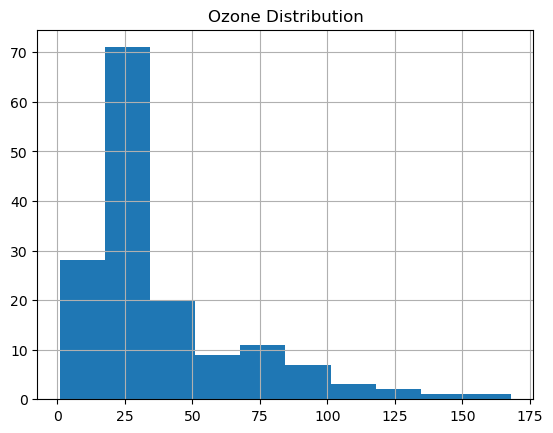

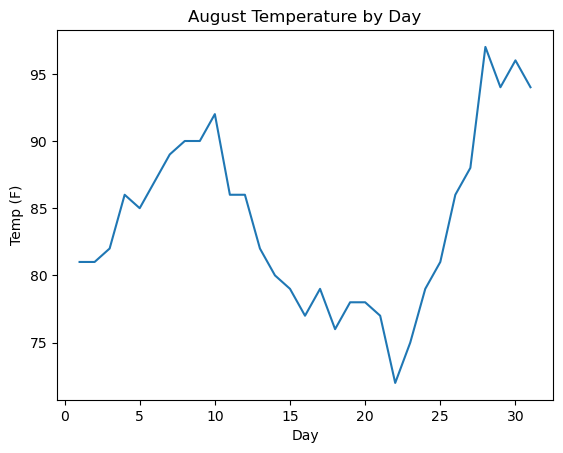

In [16]:
# Your code for Task 10 (optional) here; uncomment these lines and see
import matplotlib.pyplot as plt

# Example scaffold (uncomment and complete):
df_mv['Ozone'].hist()
plt.title('Ozone Distribution')
plt.show()

august = df[df['Month'] == 8].sort_values('Day')
plt.plot(august['Day'], august['Temp'])
plt.title('August Temperature by Day')
plt.xlabel('Day'); plt.ylabel('Temp (F)')
plt.show()

### 📊 Key Insights from the Air Quality Analysis

* **Peak Pollution & Heat (July/August):** Aggregating the data by month reveals that the mid-summer months (**July and August**) experience both the highest maximum temperatures and the highest frequency of severe ozone days (Ozone > 80 ppb). This highlights a clear correlation between rising summer heat and deteriorating air quality.
* **Missingness & Skewness Impact:** The `Ozone` and `Solar.R` columns contain notable gaps of missing data. Plotting the post-imputation histogram demonstrates that utilizing the **median** is a safer method than the mean for these columns, as it prevents the right-skewed distribution from being falsely biased by extreme pollution spikes.


### ✅ Deliverables
- Complete all code cells under each task.
- Add **one short markdown cell** summarizing **two insights** you learned (e.g., months with higher ozone, missingness patterns, hottest months).

### 📝 Evaluation (Suggested)
- **Accuracy & Correctness (40%)** – Tasks solved correctly, edge cases handled.
- **Clarity & Clean Code (20%)** – Clear variable names, comments where helpful.
- **EDA Thoroughness (20%)** – Reasonable checks and summaries beyond bare minimum.
- **Insightfulness (20%)** – Short commentary on trends/outliers/quality issues.

### Submission Format:
- Title: “PIIT Assign3 - Name” (Name your name here)
- Format: Python Notebook
### Visibility
- Git Hub Assign : https://github.com/xxxx/piit/tree/main/assign3.xxx

## Good luck & have fun!